# US Economic Conditions: 2000–Present

Publication-quality visual story of US macroeconomic conditions drawn from the FRED ELT pipeline.  
Covers unemployment, inflation vs monetary policy, and yield curve dynamics — all with NBER recession shading.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from pathlib import Path

# Locate project root (works whether notebook is run from root or notebooks/)
cwd = Path(os.getcwd())
if (cwd / '.env').exists():
    project_root = cwd
elif (cwd.parent / '.env').exists():
    project_root = cwd.parent
else:
    project_root = cwd

env_path = project_root / '.env'
images_dir = project_root / 'images'
images_dir.mkdir(parents=True, exist_ok=True)

load_dotenv(env_path)
print(f'Project root: {project_root}')
print(f'Images dir:   {images_dir}')

Project root: /Users/gretchenkolthoff/Documents/fred-economic-pipeline
Images dir:   /Users/gretchenkolthoff/Documents/fred-economic-pipeline/images


In [2]:
host = os.getenv('POSTGRES_HOST', 'localhost')
port = os.getenv('POSTGRES_PORT', '5433')
db   = os.getenv('POSTGRES_DB',   'fred_pipeline')
user = os.getenv('POSTGRES_USER', 'fred_user')
pw   = os.getenv('POSTGRES_PASSWORD', 'fred_pass')

engine = create_engine(f'postgresql+psycopg2://{user}:{pw}@{host}:{port}/{db}')

query = """
SELECT
    observation_date,
    in_recession,
    recession_name,
    unemployment_rate,
    unemployment_3m_avg,
    cpi_yoy_pct::float        AS cpi_yoy_pct,
    fed_funds_rate,
    real_fed_funds_rate,
    yield_spread_10y2y::float AS yield_spread_10y2y
FROM public_marts.fct_economic_dashboard
ORDER BY observation_date
"""

with engine.connect() as conn:
    df = pd.read_sql(text(query), conn, parse_dates=['observation_date'])

print(f'Loaded {len(df):,} rows  |  {df["observation_date"].min().date()} → {df["observation_date"].max().date()}')
print(f'Recession months: {df["in_recession"].sum()}')
df.tail(3)

Loaded 317 rows  |  2000-01-01 → 2026-05-01
Recession months: 31


,observation_date,in_recession,recession_name,unemployment_rate,unemployment_3m_avg,cpi_yoy_pct,fed_funds_rate,real_fed_funds_rate,yield_spread_10y2y
314,2026-03-01,False,NaN,4.3,4.333333,3.29,3.64,0.354042,0.531
315,2026-04-01,False,NaN,NaN,4.350000,NaN,3.64,NaN,0.520
316,2026-05-01,False,NaN,NaN,4.300000,NaN,NaN,NaN,0.498


In [3]:
# ── Publication style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.edgecolor':      '#444444',
    'axes.linewidth':      0.8,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.grid':           True,
    'grid.color':          '#e5e5e5',
    'grid.linewidth':      0.6,
    'grid.linestyle':      '-',
    'axes.labelsize':      10,
    'axes.labelcolor':     '#333333',
    'xtick.labelsize':     9,
    'ytick.labelsize':     9,
    'xtick.color':         '#555555',
    'ytick.color':         '#555555',
    'legend.fontsize':     8.5,
    'legend.frameon':      True,
    'legend.framealpha':   0.9,
    'legend.edgecolor':    '#cccccc',
    'font.family':         'DejaVu Sans',
    'figure.dpi':          150,
})

REC_COLOR = '#b0b0b0'
REC_ALPHA = 0.35

def shade_recessions(ax, df):
    """Draw gray NBER recession bands on ax."""
    rec = df.loc[df['in_recession'] == True, 'observation_date'].sort_values()
    if rec.empty:
        return
    gap    = (rec.diff() > pd.Timedelta(days=50))
    groups = gap.cumsum()
    for _, grp in rec.groupby(groups):
        ax.axvspan(grp.iloc[0], grp.iloc[-1] + pd.offsets.MonthEnd(1),
                   color=REC_COLOR, alpha=REC_ALPHA, zorder=0, lw=0)

def fmt_pct(x, _):
    return f'{x:.1f}%'

def set_date_axis(ax, df):
    ax.set_xlim(df['observation_date'].min(), df['observation_date'].max())
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))

recession_patch = Patch(facecolor=REC_COLOR, alpha=REC_ALPHA, label='Recession (NBER)', linewidth=0)

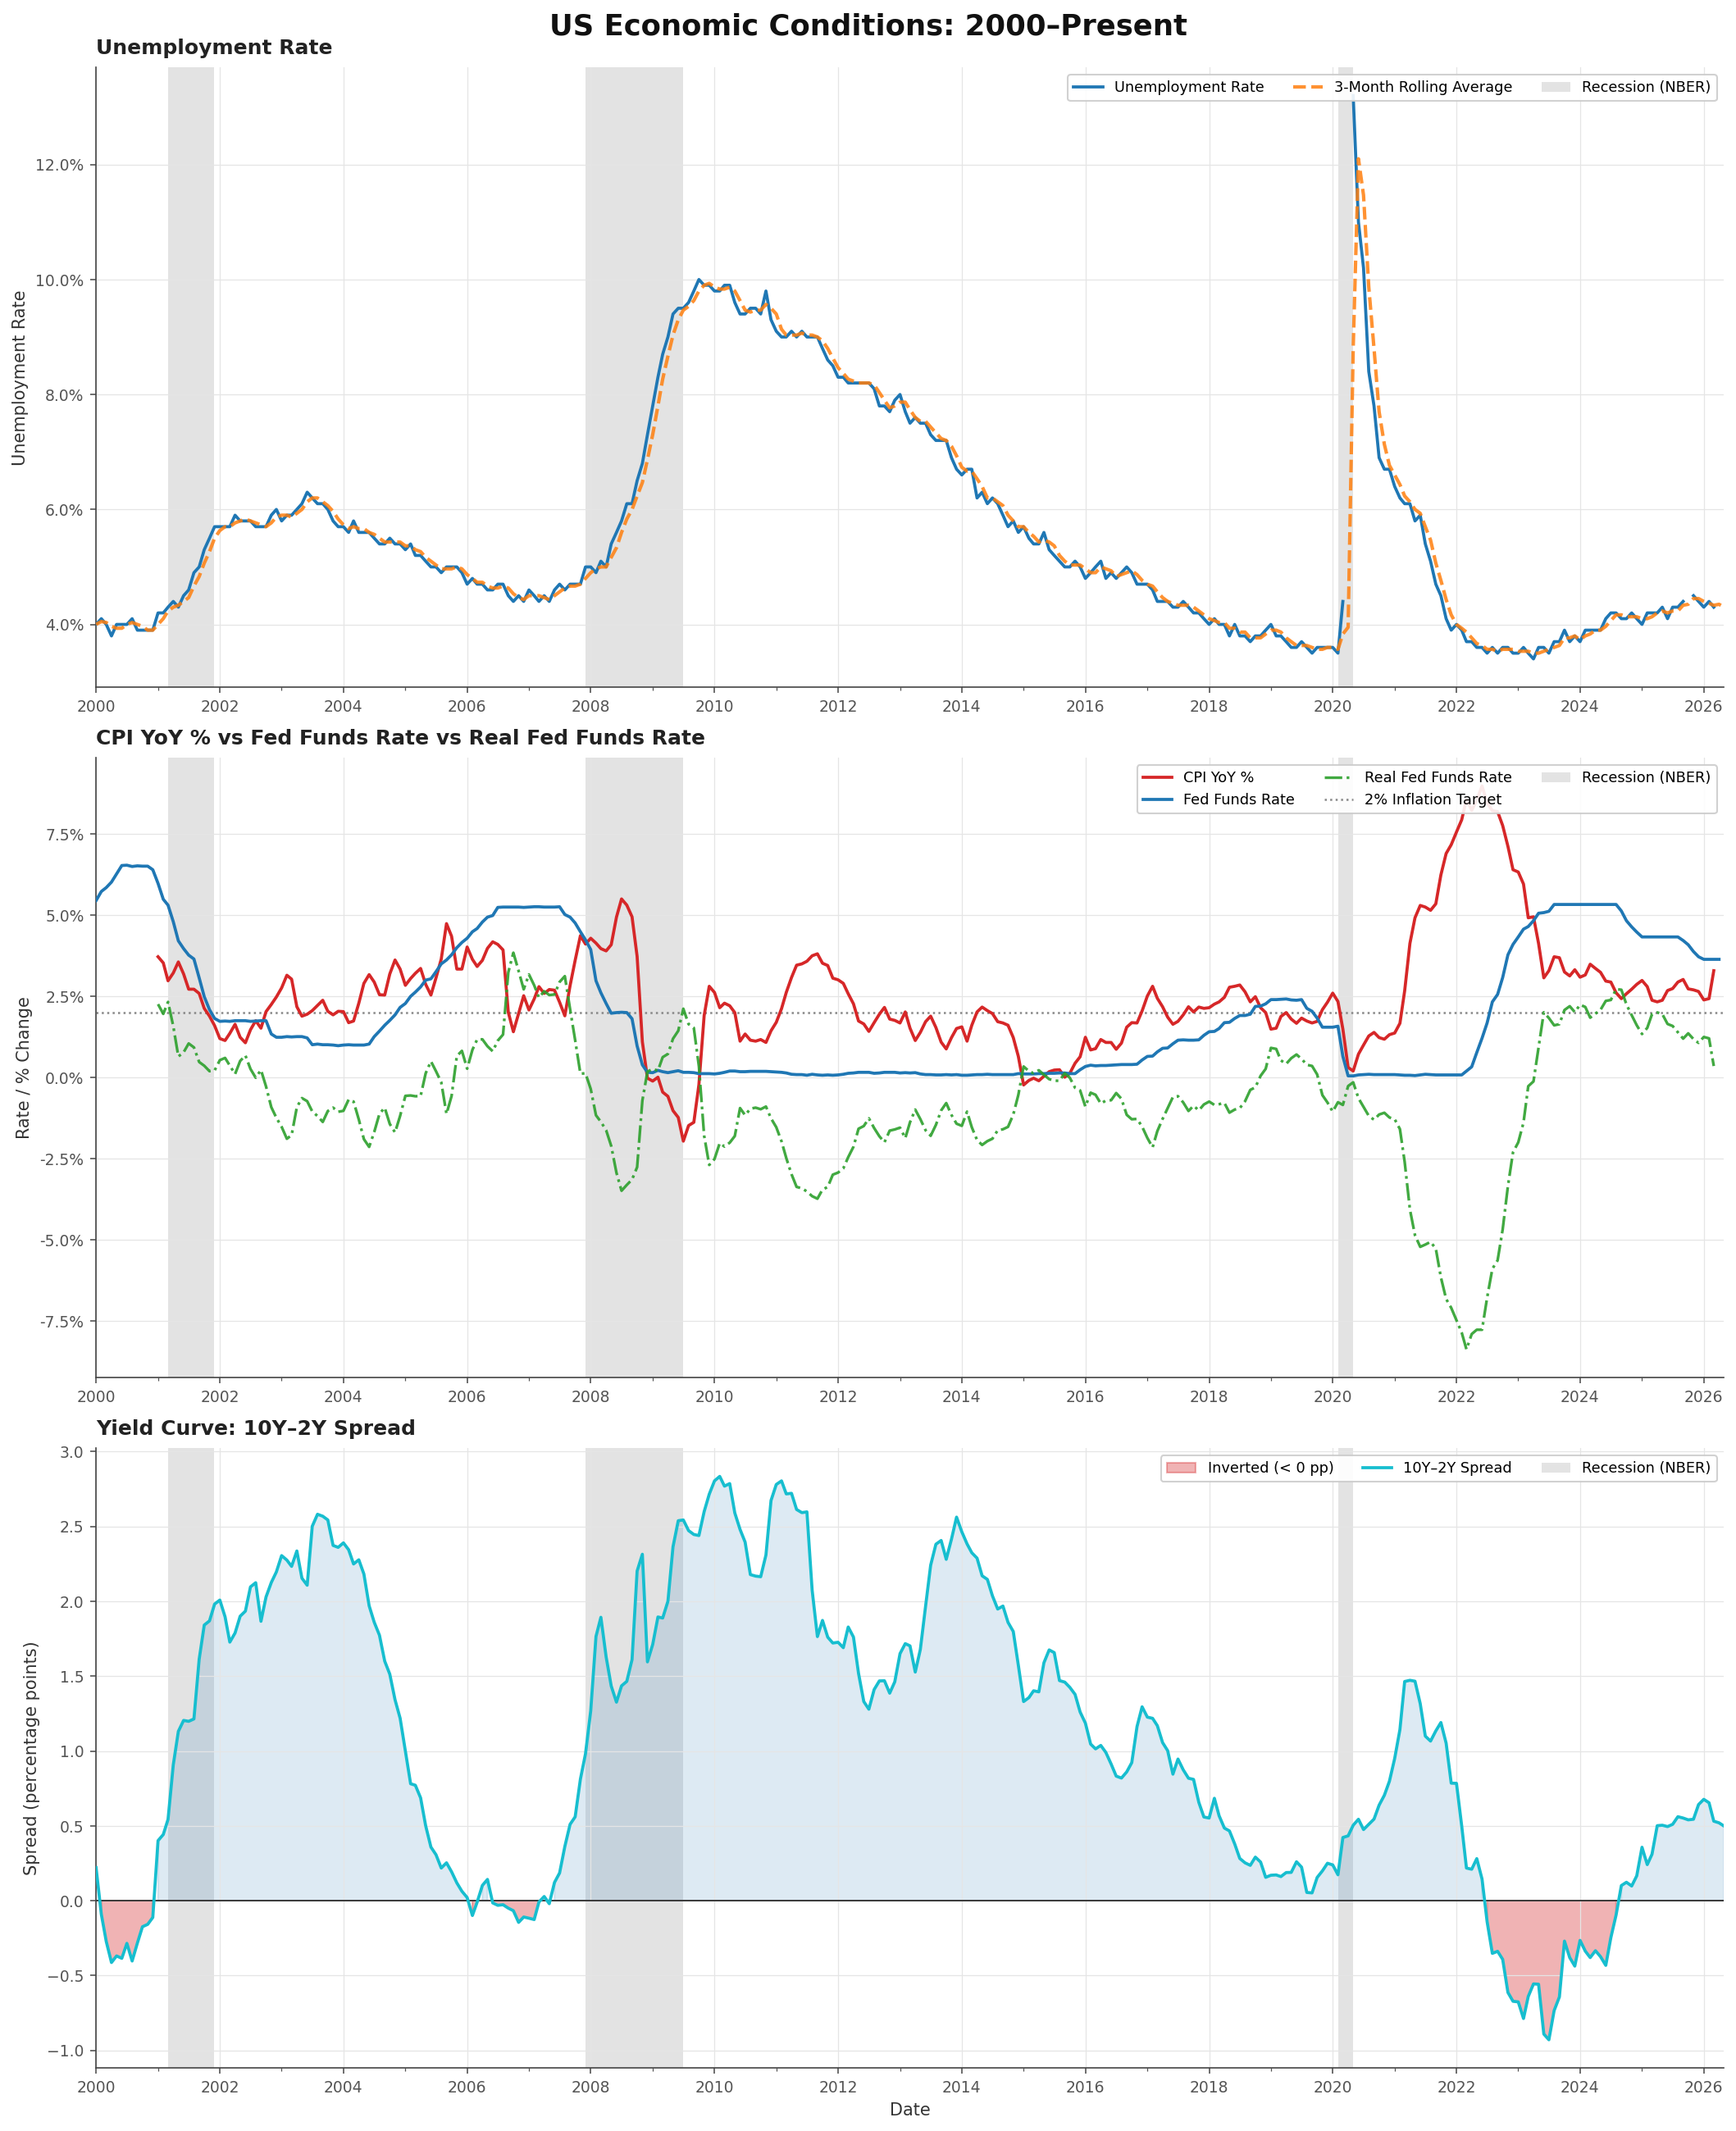


✓ Saved to: /Users/gretchenkolthoff/Documents/fred-economic-pipeline/images/economic_story.png
  File size: 438.6 KB


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 17), constrained_layout=True)

fig.suptitle('US Economic Conditions: 2000–Present',
             fontsize=17, fontweight='bold', color='#111111', y=1.01)

# ── Chart 1: Unemployment Rate ───────────────────────────────────────────────
ax1 = axes[0]
shade_recessions(ax1, df)

ax1.plot(df['observation_date'], df['unemployment_rate'],
         color='#1f77b4', linewidth=1.8, label='Unemployment Rate', zorder=3)
ax1.plot(df['observation_date'], df['unemployment_3m_avg'],
         color='#ff7f0e', linewidth=2.0, linestyle='--', alpha=0.85,
         label='3-Month Rolling Average', zorder=4)

ax1.set_title('Unemployment Rate', fontsize=12, fontweight='semibold',
              loc='left', pad=8, color='#222222')
ax1.set_ylabel('Unemployment Rate')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(fmt_pct))
set_date_axis(ax1, df)

h1, l1 = ax1.get_legend_handles_labels()
ax1.legend(handles=h1 + [recession_patch], labels=l1 + ['Recession (NBER)'],
           loc='upper right', ncol=3)

# ── Chart 2: CPI vs Fed Funds vs Real Fed Funds ──────────────────────────────
ax2 = axes[1]
shade_recessions(ax2, df)

ax2.plot(df['observation_date'], df['cpi_yoy_pct'],
         color='#d62728', linewidth=1.8, label='CPI YoY %', zorder=3)
ax2.plot(df['observation_date'], df['fed_funds_rate'],
         color='#1f77b4', linewidth=1.8, label='Fed Funds Rate', zorder=3)
ax2.plot(df['observation_date'], df['real_fed_funds_rate'],
         color='#2ca02c', linewidth=1.6, linestyle='-.', alpha=0.9,
         label='Real Fed Funds Rate', zorder=3)
ax2.axhline(2.0, color='#888888', linewidth=1.2, linestyle=':',
            label='2% Inflation Target', zorder=2)

ax2.set_title('CPI YoY % vs Fed Funds Rate vs Real Fed Funds Rate',
              fontsize=12, fontweight='semibold', loc='left', pad=8, color='#222222')
ax2.set_ylabel('Rate / % Change')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(fmt_pct))
set_date_axis(ax2, df)

h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(handles=h2 + [recession_patch], labels=l2 + ['Recession (NBER)'],
           loc='upper right', ncol=3)

# ── Chart 3: Yield Curve 10Y–2Y Spread ───────────────────────────────────────
ax3 = axes[2]
shade_recessions(ax3, df)

spread = df['yield_spread_10y2y']

ax3.fill_between(df['observation_date'], spread, 0,
                 where=(spread < 0),
                 color='#d62728', alpha=0.35, label='Inverted (< 0 pp)', zorder=1)
ax3.fill_between(df['observation_date'], spread, 0,
                 where=(spread >= 0),
                 color='#1f77b4', alpha=0.15, zorder=1)
ax3.plot(df['observation_date'], spread,
         color='#17becf', linewidth=1.8, label='10Y–2Y Spread', zorder=3)
ax3.axhline(0, color='#333333', linewidth=0.9, linestyle='-', zorder=2)

ax3.set_title('Yield Curve: 10Y–2Y Spread',
              fontsize=12, fontweight='semibold', loc='left', pad=8, color='#222222')
ax3.set_ylabel('Spread (percentage points)')
ax3.set_xlabel('Date')
set_date_axis(ax3, df)

h3, l3 = ax3.get_legend_handles_labels()
ax3.legend(handles=h3 + [recession_patch], labels=l3 + ['Recession (NBER)'],
           loc='upper right', ncol=3)

# ── Save ─────────────────────────────────────────────────────────────────────
output_path = images_dir / 'economic_story.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'\n✓ Saved to: {output_path}')
print(f'  File size: {output_path.stat().st_size / 1024:.1f} KB')